## CALCULATE THE DISTANCE BETWEEN THE ORIGINAL, THE RANDOM and OUR GENERATOR

In [1]:
!pip install umap-learn

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

import altair as alt
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [2]:
## import the ordinal encoded dataset
df = pd.read_csv('../../datasets/enc_dataset.csv')
df_ourgen = pd.read_csv('../../datasets/neighbourhood_57.csv')

In [3]:
#import the one-hot-encoded random df
df_random=pd.read_csv('../../datasets/random_n_dataset.csv')
df_random.head()

,Week6_Covid=NONE,Week6_Covid=AND,Week6_Covid=LMM,Week6_Covid=HM,Week6_Covid=HMM,Week5_Covid=NONE,Week5_Covid=AND,Week5_Covid=LMM,Week5_Covid=HM,Week5_Covid=HMM,...,Week2_Mobility=NONE,Week2_Mobility=NM,Week2_Mobility=SH,Week2_Mobility=DM,Week2_Mobility=IM,Week1_Mobility=NONE,Week1_Mobility=NM,Week1_Mobility=SH,Week1_Mobility=DM,Week1_Mobility=IM
0,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,0
3,0,1,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [4]:
df=df.drop("Class_label", axis=1)

In [5]:
df= df.astype(int)

In [6]:
df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,1,1,0,0,0,0,1,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,1,1
2,2,2,2,2,2,2,2,3,3,3,3,3
3,0,0,0,1,1,1,0,0,0,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1


In [7]:
data_np=df.to_numpy()

#### Change the one hot encoded structure df

In [8]:
# Initialize an empty DataFrame
decoded_random_df = pd.DataFrame(index=df_random.index)

# Loop over each column and process
for column in df_random.columns:
    col_name, col_value = column.split('=')  # Split the column name

    
    # Check where the original DataFrame has a 1 (i.e., is 'hot'), and set that value
    decoded_random_df.loc[df_random[column] == 1, col_name] = col_value
decoded_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,HMM,HM,AND,LMM,AND,NONE,NM,DM,NONE,IM,NONE,SH
1,HM,LMM,AND,LMM,HMM,HMM,NM,IM,SH,DM,IM,NM
2,AND,HMM,AND,NONE,NONE,HM,DM,SH,IM,NONE,IM,NONE
3,AND,HM,HM,LMM,AND,LMM,SH,NONE,NONE,SH,NONE,NONE
4,NONE,NONE,HMM,LMM,HMM,HMM,SH,DM,NM,SH,DM,DM


In [9]:
decoded_random_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Week6_Covid     100 non-null    object
 1   Week5_Covid     100 non-null    object
 2   Week4_Covid     100 non-null    object
 3   Week3_Covid     100 non-null    object
 4   Week2_Covid     100 non-null    object
 5   Week1_Covid     100 non-null    object
 6   Week6_Mobility  100 non-null    object
 7   Week5_Mobility  100 non-null    object
 8   Week4_Mobility  100 non-null    object
 9   Week3_Mobility  100 non-null    object
 10  Week2_Mobility  100 non-null    object
 11  Week1_Mobility  100 non-null    object
dtypes: object(12)
memory usage: 9.5+ KB


In [10]:
#### Ordinal encode the random df

covid_categories = ['NONE', 'AND', 'LMM', 'HM', 'HMM']
mobility_categories = ['NONE', 'NM', 'DM', 'SH', 'IM']

enc = OrdinalEncoder(categories=[covid_categories for i in range(6)] + [mobility_categories for i in range(6)])
 
enc_random= enc.fit_transform(decoded_random_df)

enc_random_df = pd.DataFrame(enc_random)
enc_random_df.columns = df.columns.tolist()

In [11]:
enc_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,4.0,3.0,1.0,2.0,1.0,0.0,1.0,2.0,0.0,4.0,0.0,3.0
1,3.0,2.0,1.0,2.0,4.0,4.0,1.0,4.0,3.0,2.0,4.0,1.0
2,1.0,4.0,1.0,0.0,0.0,3.0,2.0,3.0,4.0,0.0,4.0,0.0
3,1.0,3.0,3.0,2.0,1.0,2.0,3.0,0.0,0.0,3.0,0.0,0.0
4,0.0,0.0,4.0,2.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,2.0


In [12]:
enc_random_df= enc_random_df.astype(int)

In [13]:
enc_random_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Week6_Covid     100 non-null    int64
 1   Week5_Covid     100 non-null    int64
 2   Week4_Covid     100 non-null    int64
 3   Week3_Covid     100 non-null    int64
 4   Week2_Covid     100 non-null    int64
 5   Week1_Covid     100 non-null    int64
 6   Week6_Mobility  100 non-null    int64
 7   Week5_Mobility  100 non-null    int64
 8   Week4_Mobility  100 non-null    int64
 9   Week3_Mobility  100 non-null    int64
 10  Week2_Mobility  100 non-null    int64
 11  Week1_Mobility  100 non-null    int64
dtypes: int64(12)
memory usage: 9.5 KB


In [14]:
enc_random_np=enc_random_df.to_numpy()

In [15]:
df_ourgen.head()

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,2,3,3,2,1,2,1,315,77
1,1,2,2,2,3,2,3,161,56
2,3,1,3,1,1,2,2,42,49
3,1,3,3,3,2,2,3,287,119
4,3,4,3,3,4,4,3,126,140


In [16]:
ourgen_np=df_ourgen.to_numpy()

In [17]:
ourgen_np

array([[  2,   3,   3,   2,   1,   2,   1, 315,  77],
       [  1,   2,   2,   2,   3,   2,   3, 161,  56],
       [  3,   1,   3,   1,   1,   2,   2,  42,  49],
       [  1,   3,   3,   3,   2,   2,   3, 287, 119],
       [  3,   4,   3,   3,   4,   4,   3, 126, 140],
       [  3,   3,   2,   2,   2,   2,   2,  77, 119],
       [  4,   3,   3,   1,   1,   2,   3, 434, 147],
       [  2,   3,   3,   4,   2,   3,   1, 308,  84],
       [  3,   3,   3,   2,   4,   4,   3, 210, 140],
       [  3,   2,   3,   1,   3,   3,   2, 140,  21],
       [  3,   4,   4,   3,   3,   3,   2,  70,   7],
       [  3,   3,   2,   2,   1,   1,   1, 392,  91],
       [  4,   4,   3,   3,   3,   3,   3, 126, 119],
       [  2,   2,   1,   3,   2,   3,   4, 336, 133],
       [  1,   1,   3,   2,   2,   2,   3, 210,  84],
       [  1,   2,   3,   3,   4,   4,   4, 140, 133],
       [  2,   3,   3,   1,   1,   1,   1, 273,  49],
       [  3,   4,   4,   2,   2,   4,   1, 357,  14],
       [  3,   2,   1,   2, 

### COMPUTE THE DISTANCE

In [19]:
distances = pairwise_distances( data_np, ourgen_np, metric='euclidean')

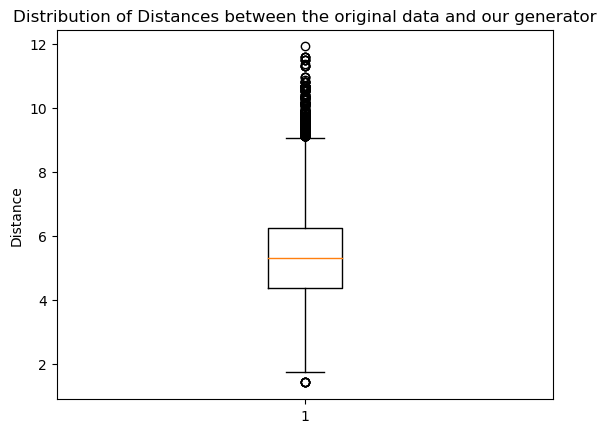

In [20]:
distances_flat = distances.flatten()
plt.boxplot(distances_flat)
plt.title('Distribution of Distances between the original data and our generator')
plt.ylabel('Distance')
plt.show()

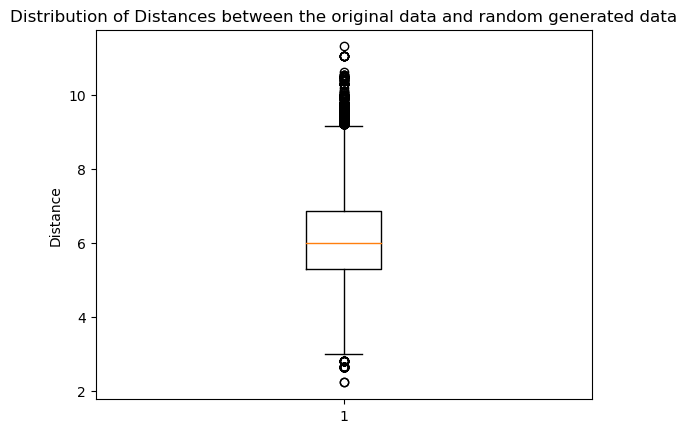

In [21]:
distances_r = pairwise_distances( data_np,enc_random_np, metric='euclidean')
distances_flat_r = distances_r.flatten()
plt.boxplot(distances_flat_r)
plt.title('Distribution of Distances between the original data and random generated data')
plt.ylabel('Distance')
plt.show()

In [22]:
alt_df_dist = pd.DataFrame(distances_flat, columns=['Distance'])
boxplot_1 = alt.Chart(alt_df_dist ).mark_boxplot().encode(
    alt.X("Distance:Q").scale(zero=False)
).properties(
    height=300,
    width=500,
    title= 'Our Generated Data'
)

alt_df_dist_r = pd.DataFrame(distances_flat_r, columns=['Distance'])
boxplot_2 = alt.Chart(alt_df_dist_r).mark_boxplot().encode(
    alt.X("Distance:Q").scale(zero=False)
).properties(
    height=300,
    width=500,
    title= 'Random Generated Data'
)

boxplot_1 | boxplot_2

alt.HConcatChart(...)

In [23]:
#create df for altair
alt_df_dist['source']='our'
alt_df_dist_r['source']='random'
boxplot_df = pd.concat([alt_df_dist, alt_df_dist_r], axis=0)

In [24]:
alt.Chart(boxplot_df ).mark_boxplot().encode(
    alt.X("Distance:Q").scale(zero=False),
    alt.Y("source:N"),
    alt.Color("source:N")
).properties(
    height=300,
    width=500,
    title= 'Distances with the original Data'
)
#change distance function: modified version

alt.Chart(...)

### ORDER GENERATED DATA BASED ON THEIR SIMILARITY

In [57]:
sorted_indices = np.argsort(distances)
m3 = ourgen_np[sorted_indices[::-1]]  # m3 is m2 sorted by decreasing similarity

In [58]:
m3

array([[[4, 3, 3, ..., 1, 2, 2],
        [4, 3, 3, ..., 1, 1, 1],
        [3, 3, 4, ..., 2, 2, 2],
        ...,
        [1, 1, 1, ..., 4, 4, 2],
        [3, 2, 2, ..., 4, 4, 4],
        [2, 2, 3, ..., 4, 4, 4]],

       [[4, 3, 3, ..., 1, 1, 1],
        [4, 4, 4, ..., 1, 2, 2],
        [3, 3, 4, ..., 2, 2, 2],
        ...,
        [1, 1, 2, ..., 3, 3, 4],
        [1, 2, 1, ..., 4, 4, 3],
        [1, 1, 1, ..., 4, 4, 2]],

       [[1, 1, 2, ..., 1, 1, 3],
        [1, 1, 1, ..., 1, 2, 2],
        [2, 2, 2, ..., 2, 2, 1],
        ...,
        [3, 3, 3, ..., 4, 4, 1],
        [3, 2, 2, ..., 4, 4, 4],
        [2, 2, 3, ..., 4, 4, 4]],

       ...,

       [[1, 1, 2, ..., 3, 2, 4],
        [3, 2, 3, ..., 2, 3, 3],
        [1, 2, 1, ..., 2, 2, 3],
        ...,
        [2, 1, 4, ..., 1, 3, 4],
        [4, 4, 4, ..., 1, 3, 2],
        [1, 3, 4, ..., 1, 1, 2]],

       [[1, 1, 1, ..., 2, 2, 2],
        [1, 1, 1, ..., 1, 2, 2],
        [1, 1, 2, ..., 1, 1, 3],
        ...,
        [3, 2, 2, ..., 

In [32]:
enc_random_df['source']='random'
df_ourgen['source']='our'
df['source']='original'

In [64]:
combined_df = pd.concat([df, df_ourgen, enc_random_df], axis=0)

In [56]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Week6_Covid     599 non-null    int64 
 1   Week5_Covid     599 non-null    int64 
 2   Week4_Covid     599 non-null    int64 
 3   Week3_Covid     599 non-null    int64 
 4   Week2_Covid     599 non-null    int64 
 5   Week1_Covid     599 non-null    int64 
 6   Week6_Mobility  599 non-null    int64 
 7   Week5_Mobility  599 non-null    int64 
 8   Week4_Mobility  599 non-null    int64 
 9   Week3_Mobility  599 non-null    int64 
 10  Week2_Mobility  599 non-null    int64 
 11  Week1_Mobility  599 non-null    int64 
 12  source          599 non-null    object
dtypes: int64(12), object(1)
memory usage: 65.5+ KB


### TSNE
The ordering of the inputs match the ordering of the outputs

In [35]:
combined_data = np.vstack((data_np, enc_random_np, ourgen_np))

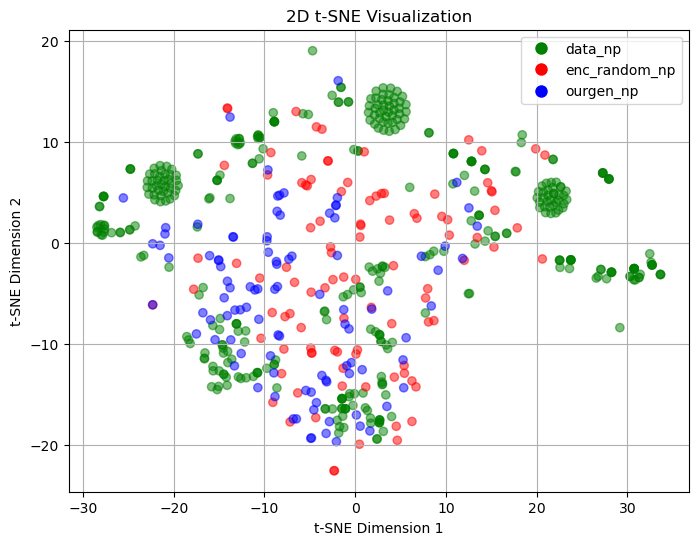

In [36]:
# Initialize t-SNE object with desired parameters
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data = tsne.fit_transform(combined_data)

# Define colors for each array
color_data = ['green'] * len(data_np)
color_random = ['red'] * len(enc_random_np)
color_ourgen = ['blue'] * len(ourgen_np)

# Concatenate color lists
colors = color_data + color_random + color_ourgen

# Plot 2D t-SNE visualization with color coding
plt.figure(figsize=(8, 6))
plt.scatter(embedded_data[:, 0], embedded_data[:, 1], c=colors[:len(embedded_data)], alpha=0.5)

legend1 = plt.Line2D([0], [0], marker='o', color='w', label='data_np', markerfacecolor='green', markersize=10)
legend2 = plt.Line2D([0], [0], marker='o', color='w', label='enc_random_np', markerfacecolor='red', markersize=10)
legend3 = plt.Line2D([0], [0], marker='o', color='w', label='ourgen_np', markerfacecolor='blue', markersize=10)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Visualization')
plt.grid(True)
plt.legend(handles=[legend1, legend2, legend3])
plt.grid(True)
plt.show()

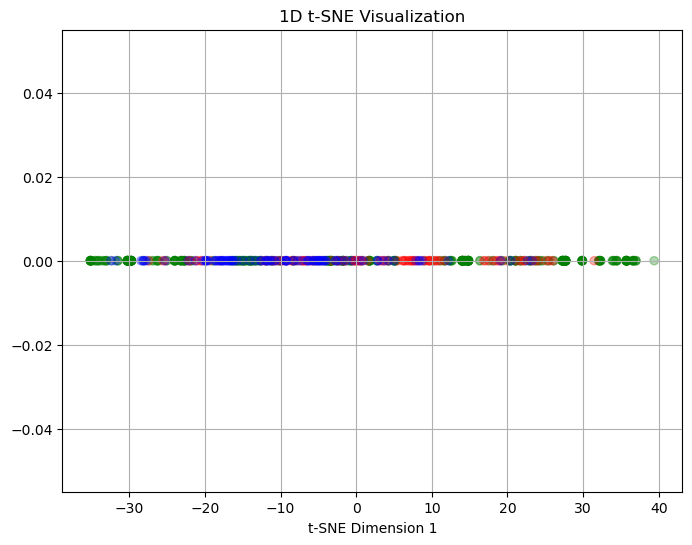

In [37]:
# Initialize t-SNE object with 1 components
tsne_1d = TSNE(n_components=1, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data_1d = tsne_1d.fit_transform(combined_data)
plt.figure(figsize=(8, 6))
plt.scatter(embedded_data_1d[:, 0], np.zeros_like(embedded_data_1d[:, 0]), c=colors[:len(embedded_data)], alpha=0.3)
plt.xlabel('t-SNE Dimension 1')
plt.title('1D t-SNE Visualization')
plt.grid(True)
plt.show()

In [38]:
embedded_data_1d

array([[ 29.898926  ],
       [ 27.304605  ],
       [ -3.478124  ],
       [ 35.72467   ],
       [ 27.299927  ],
       [-26.916811  ],
       [ 14.829178  ],
       [-13.651892  ],
       [-21.731339  ],
       [ -0.66324836],
       [ 32.26537   ],
       [  4.060481  ],
       [-34.57407   ],
       [-35.11832   ],
       [ 14.413601  ],
       [-35.11875   ],
       [-28.162792  ],
       [-22.743582  ],
       [-22.74345   ],
       [  1.7652129 ],
       [ 35.72467   ],
       [-14.570565  ],
       [  5.110805  ],
       [-29.740162  ],
       [ 34.010113  ],
       [ 14.410541  ],
       [-13.940479  ],
       [ 32.095802  ],
       [-23.983168  ],
       [  5.2091866 ],
       [-13.775562  ],
       [-35.118637  ],
       [ 14.80517   ],
       [ -8.426531  ],
       [-23.13955   ],
       [-23.139563  ],
       [ 34.45062   ],
       [-29.73925   ],
       [ -3.0436835 ],
       [-33.041023  ],
       [-29.739298  ],
       [ 27.673418  ],
       [-23.98319   ],
       [-29

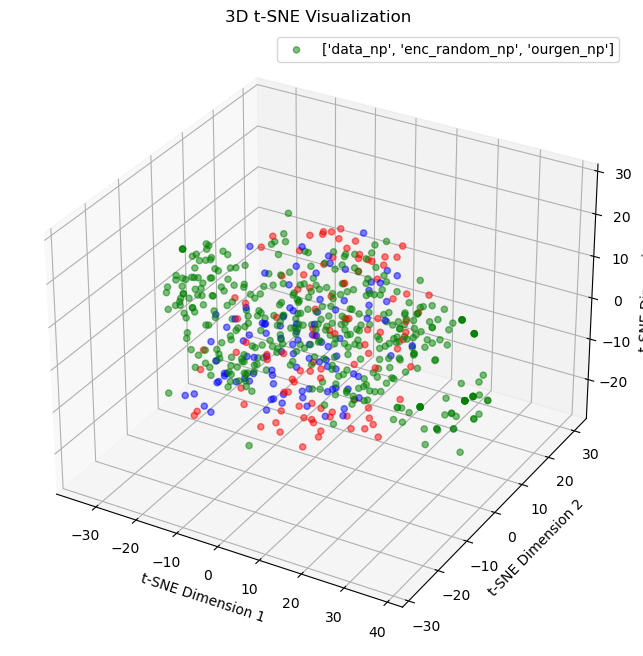

In [39]:
# Initialize t-SNE object with 3 components
tsne_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data_3d = tsne_3d.fit_transform(combined_data)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedded_data_3d[:, 0], embedded_data_3d[:, 1], embedded_data_3d[:, 2],c=colors[:len(embedded_data)], alpha=0.5,label=['data_np', 'enc_random_np', 'ourgen_np'])
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_zlabel('t-SNE Dimension 3')
ax.legend()
ax.set_title('3D t-SNE Visualization')
plt.show()

#### ORDER WITH 1-D T-SNE

In [40]:
tsne_values = embedded_data_1d.flatten()

In [41]:
#attach tsne values to the df
df_tsne = combined_df
df_tsne['TSNE'] = tsne_values

In [42]:
df_tsne.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source,TSNE
0,1,1,0,0,0,0,1,1,0,0,0,0,original,29.898926
1,1,1,1,1,1,1,1,1,1,1,1,1,original,27.304605
2,2,2,2,2,2,2,2,3,3,3,3,3,original,-3.478124
3,0,0,0,1,1,1,0,0,0,1,1,1,original,35.724670
4,1,1,1,1,1,1,1,1,1,1,1,1,original,27.299927


In [43]:
#sort
df_tsne = df_tsne.sort_values(by='TSNE', ascending=False)
df_tsne['Index'] = df_tsne.index

In [44]:
df_tsne.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source,TSNE,Index
249,1,0,1,1,1,1,1,0,1,1,1,1,original,39.389175,249
373,0,0,0,0,2,2,0,0,0,0,1,1,original,36.977749,373
276,0,0,0,0,2,2,0,0,0,0,1,1,original,36.977749,276
291,0,0,0,0,2,2,0,0,0,0,1,1,original,36.977707,291
183,0,0,0,0,0,1,0,0,0,0,0,1,original,36.635899,183


In [87]:
tsne_plot = alt.Chart(df_tsne).mark_bar(tooltip=True).encode(
    x=alt.X('Index:O', title='Data Points', sort=None),
    y=alt.Y('TSNE:Q', title='t-SNE Value')
).properties(
    title='1-D t-SNE Values Ordered Decreasingly'
)
tsne_plot 

alt.Chart(...)

## UMap

In [45]:
from umap import UMAP

2024-05-16 10:14:44.768170: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
import plotly.express as px

In [58]:
combined_df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source
0,1,1,0,0,0,0,1,1,0,0,0,0,original
1,1,1,1,1,1,1,1,1,1,1,1,1,original
2,2,2,2,2,2,2,2,3,3,3,3,3,original
3,0,0,0,1,1,1,0,0,0,1,1,1,original
4,1,1,1,1,1,1,1,1,1,1,1,1,original
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,3,1,3,2,4,1,4,4,0,2,2,random
96,0,4,2,3,1,1,3,0,0,1,3,4,random
97,3,0,2,1,2,2,4,0,3,1,2,4,random
98,4,2,0,4,1,4,2,3,1,4,3,0,random


In [61]:
features=combined_df.loc[:,:'Week1_Mobility']

umap1d=UMAP(n_components=1, init='random', random_state=0)
proj_2d=umap1d.fit_transform(features)

/opt/anaconda3/envs/xai/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [62]:
features

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,1,1,0,0,0,0,1,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,1,1
2,2,2,2,2,2,2,2,3,3,3,3,3
3,0,0,0,1,1,1,0,0,0,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,3,1,3,2,4,1,4,4,0,2,2
96,0,4,2,3,1,1,3,0,0,1,3,4
97,3,0,2,1,2,2,4,0,3,1,2,4
98,4,2,0,4,1,4,2,3,1,4,3,0


In [63]:
proj_2d

array([[-13.944853  ],
       [-28.699537  ],
       [ 12.59714   ],
       [ 47.390266  ],
       [-29.009644  ],
       [  9.900333  ],
       [ 38.53518   ],
       [  7.6776056 ],
       [ 17.940798  ],
       [ 11.789715  ],
       [ 24.197474  ],
       [ 10.327745  ],
       [  4.499045  ],
       [ -2.469783  ],
       [ 38.480347  ],
       [ -2.3618627 ],
       [ 37.006332  ],
       [ 18.7715    ],
       [ 18.758278  ],
       [ 11.036311  ],
       [ 47.318275  ],
       [  7.4471197 ],
       [ 10.2811775 ],
       [-37.90775   ],
       [-25.613777  ],
       [ 38.243824  ],
       [  7.7003083 ],
       [ 24.080376  ],
       [ 18.532917  ],
       [ 10.325226  ],
       [  7.6271887 ],
       [ -2.4406056 ],
       [ 38.046757  ],
       [  9.665721  ],
       [ 18.556175  ],
       [ 18.39979   ],
       [-25.584791  ],
       [-37.564102  ],
       [ 12.8738165 ],
       [ -1.0138927 ],
       [-37.564514  ],
       [-28.514193  ],
       [ 18.428972  ],
       [-37

In [65]:
umap_values = proj_2d.flatten()

In [66]:
df_umap = combined_df
df_umap['UMAP'] = umap_values

In [67]:
df_umap = df_umap.sort_values(by='UMAP', ascending=False)
df_umap['Index'] = df_umap.index

In [72]:
df_umap.head(30)

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source,UMAP,Index
370,0,0,0,1,1,1,0,0,0,1,1,1,original,47.439869,370
104,0,0,0,1,1,1,0,0,0,1,1,1,original,47.439762,104
242,0,0,0,1,1,1,0,0,0,1,1,1,original,47.420845,242
152,0,0,0,1,1,1,0,0,0,1,1,1,original,47.391056,152
3,0,0,0,1,1,1,0,0,0,1,1,1,original,47.390266,3
82,0,0,0,1,1,1,0,0,0,1,1,1,original,47.388718,82
68,0,0,0,1,1,1,0,0,0,1,1,1,original,47.387463,68
109,0,0,0,1,1,1,0,0,0,1,1,1,original,47.376556,109
166,0,0,0,1,1,1,0,0,0,1,1,1,original,47.369747,166
114,0,0,0,1,1,1,0,0,0,1,1,1,original,47.366173,114


In [69]:
df_tsne_umap=combined_df
df_tsne_umap['UMAP']=umap_values
df_tsne_umap['TSNE']=tsne_values

In [70]:
df_tsne_umap.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source,UMAP,TSNE
0,1,1,0,0,0,0,1,1,0,0,0,0,original,-13.944853,29.898926
1,1,1,1,1,1,1,1,1,1,1,1,1,original,-28.699537,27.304605
2,2,2,2,2,2,2,2,3,3,3,3,3,original,12.597140,-3.478124
3,0,0,0,1,1,1,0,0,0,1,1,1,original,47.390266,35.724670
4,1,1,1,1,1,1,1,1,1,1,1,1,original,-29.009644,27.299927


### USELESS plot

In [71]:
alt.Chart(df_tsne_umap).mark_circle(size=60).encode(
    x='UMAP:Q',
    y='TSNE:Q',
    color='source:N',
    tooltip=['source']
).properties(
    width=500,
    height=500
)

alt.Chart(...)

### OLD STUFF

In [ ]:
#need to change the structure of the df
df_ordered_our['id'] = df_ordered_our.index  # Create a new column to preserve the row index

# Melt the DataFrame
alt_our_df = pd.melt(df_ordered_our, id_vars=['id'], var_name='Week_Metric', value_name='Value')

alt_our_df.head(20)

In [ ]:
domain_ = ['AND', 'LMM', 'HM', 'HMM','NM','DM','SH','IM']
range_= ['#264653', '#2a9d8f', '#e9c46a', '#f4a261','#264653','#2a9d8f','#e76f51','#c9f0eb'] #evitare conflitti con funzione predefinita

week_order = [
    'Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week2_Covid', 'Week1_Covid',
    'Week6_Mobility', 'Week5_Mobility', 'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility'
]


alt.Chart(alt_our_df).mark_rect().encode(
    x=alt.X('Week_Metric:N', sort=week_order, axis=alt.Axis(labelAngle=0, title=None, ticks=False, grid=False, orient='top')),
    y=alt.Y('id:O',axis=alt.Axis(ticks=False, title=None, grid=False, labels=False) ),
    color=alt.Color('Value'),
    tooltip=['Week_Metric', 'Value']
).properties(
    title="COVID and Mobility Data Over Six Weeks",
    width=900,
    height=900
)

In [ ]:
#Distances between original data and generates neigh
dist_matrix_r = distance.cdist(data_np, enc_random_np, 'euclidean')

# Find the index of the closest vector in generates neigh for each vector in the original data
closest_indices = np.argmin(dist_matrix, axis=1)
closest_vectors_r = enc_random_np[closest_indices]

In [ ]:
similarity_scores_r = np.sum(dist_matrix_r, axis=0)

In [ ]:
similarity_scores_r

In [ ]:
sorted_indices_r = np.argsort(similarity_scores_r)
m4 = enc_random_np[sorted_indices_r[::-1]]  # m3 is m2 sorted by decreasing similarity

In [ ]:
m4

In [ ]:
'''
# Combine two np
combined_data = np.vstack((data_np, ourgen_np,))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='our data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''

In [ ]:
'''
# Combine two np
combined_data = np.vstack((data_np, enc_random_np))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='random data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''

In [ ]:
#generate multiple neighbourhoods send the result in CSV so that they can apply the visualization